In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install emoji
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pandas as pd
import emoji
import re

In [ ]:
swu = pd.read_parquet('/content/drive/MyDrive/IS488614/standwithus_raw_comments.parquet')
joc = pd.read_parquet('/content/drive/MyDrive/IS488614/jewishoncampus_raw_comments.parquet')

# Globally standardize skin tone modifiers to base/yellow emojis for consistency
swu['text'] = swu['text'].astype(str).str.replace(r'[\U0001F3FB-\U0001F3FF]', '', regex=True)
joc['text'] = joc['text'].astype(str).str.replace(r'[\U0001F3FB-\U0001F3FF]', '', regex=True)

display(swu)
display(joc)

### Preprocessing Data: Counting and DeCoding Emojis

The LLM will have a hard time understanding emojis in their raw unicode format. To make it digestible, I will replace these unicodes with the literal meanings, then combine certain bigrams and trigrams into unique tokens to enhance their meanings.

In [ ]:
def scan_emojis(df, text_column):
    """
    Scans a DataFrame column and returns a ranked list of all emojis present in the dataset.
    """
    print("Scanning for emojis...")
    all_emojis_found = []

    # Iterate through the raw text column
    for raw_text in df[text_column].dropna():
        # Extract emojis directly from the string
        extracted = emoji.emoji_list(str(raw_text))

        # Pull just the emoji characters out and add them to our master list
        for item in extracted:
            all_emojis_found.append(item['emoji'])

    # Count the frequencies
    emoji_counts = Counter(all_emojis_found)

    return emoji_counts

# 2. Execute function on each dataframe
swu_emojis = scan_emojis(swu, 'text')
joc_emojis = scan_emojis(joc, 'text')

# 3. Visualize the top 20 most frequently used emojis in the dataset
def plot_top_emojis(emoji_counts, title, ax):
    top_emojis = emoji_counts.most_common(20)
    # Use demojized names for better rendering in matplotlib
    emojis = [emoji.demojize(e[0]).strip(':') for e in top_emojis]
    counts = [e[1] for e in top_emojis]

    sns.barplot(x=counts, y=emojis, ax=ax, palette="viridis")
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.set_ylabel('Emoji')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_top_emojis(swu_emojis, 'Top 20 Emojis in SWU', axes[0])
plot_top_emojis(joc_emojis, 'Top 20 Emojis in JOC', axes[1])

plt.tight_layout()
plt.show()

### Bigrams and Trigrams: Encoding Common Sequences For Deeper Meaning
In sentiment analysis we aim to capture emotional responses, so emoji bigrams and trigrams convey those pretty clearly. First I will add an emotional intensity marker to encode repetition. Next any significant mixed sequence will receive a custom, hardcoded token.

In [ ]:
def get_emoji_sequences(df, text_column):
    sequence_counts = Counter()

    for raw_text in df[text_column].dropna():
        # Extract emojis, preserving order and repetition
        extracted = emoji.emoji_list(str(raw_text))
        emojis_in_text = [item['emoji'] for item in extracted]

        # Find consecutive sequences (bigrams and trigrams)
        if len(emojis_in_text) >= 2:
            # Bigrams (pairs)
            bigrams = [tuple(emojis_in_text[i:i+2]) for i in range(len(emojis_in_text) - 1)]
            sequence_counts.update(bigrams)

        if len(emojis_in_text) >= 3:
            # Trigrams (triplets)
            trigrams = [tuple(emojis_in_text[i:i+3]) for i in range(len(emojis_in_text) - 2)]
            sequence_counts.update(trigrams)

    return sequence_counts

# Execute function on each dataframe
swu_seqs = get_emoji_sequences(swu, 'text')
joc_seqs = get_emoji_sequences(joc, 'text')

# Visualize the top 20 most frequently co-occurring emoji sequences in the dataset
def plot_top_sequences(seq_counts, title, ax):
    top_seqs = seq_counts.most_common(20)
    # Use demojized names for sequence rendering in matplotlib
    seqs = [emoji.demojize(''.join(e[0])) for e in top_seqs]
    counts = [e[1] for e in top_seqs]

    sns.barplot(x=counts, y=seqs, ax=ax, palette="plasma")
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.set_ylabel('Emoji Sequence')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_top_sequences(swu_seqs, 'Top 20 Emoji Sequences in SWU', axes[0])
plot_top_sequences(joc_seqs, 'Top 20 Emoji Sequences in JOC', axes[1])

plt.tight_layout()
plt.show()

In [ ]:
def encode_emoji_intensity(text):
    """
    Replaces sequences of 2 or more identical emojis with an INTENSE text token.
    Single emojis are left untouched (they can be demojized later if needed).
    """
    if not isinstance(text, str):
        return text

    # 1. Extract unique emojis present in this specific string
    extracted = emoji.emoji_list(text)
    unique_emojis = set([item['emoji'] for item in extracted])

    # 2. For each unique emoji, build a regex to find 2+ consecutive occurrences
    for emj in unique_emojis:
        # Escape the emoji for safe regex matching (some emojis have special chars like * or +)
        escaped_emj = re.escape(emj)

        # Pattern: Match the specific emoji repeated 2 or more times
        pattern = f"({escaped_emj}{{2,}})"

        def replacer(match):
            # Demojize the single emoji to get its textual name (e.g., ':crying_face:')
            emoji_name = emoji.demojize(emj).strip(':').upper()
            return f" INTENSE_{emoji_name} "

        # Substitute the matched sequence with our intensity tag
        text = re.sub(pattern, replacer, text)

    return text

# --- Apply to the dataframes ---
swu['text_encoded'] = swu['text'].apply(encode_emoji_intensity)
joc['text_encoded'] = joc['text'].apply(encode_emoji_intensity)

print("Top Mixed Sequences in SWU:")
for seq, count in swu_seqs.most_common(50):
    if len(set(seq)) > 1:
        print(f"{''.join(seq)} : {count}")

print("\nTop Mixed Sequences in JOC:")
for seq, count in joc_seqs.most_common(50):
    if len(set(seq)) > 1:
        print(f"{''.join(seq)} : {count}")

In [ ]:
def encode_mixed_sequences(text):
    """
    Replaces specific mixed or alternating emoji sequences with descriptive text tokens.
    """
    if not isinstance(text, str):
        return text

    # Define the mixed sequences identified in our earlier bigram/trigram EDA
    # Trigrams are listed first to ensure they are replaced before overlapping bigrams
    mixed_sequences = {
        '🖕🇮🇱🖕': ' MIDDLE_FINGER_ISRAEL_MIDDLE_FINGER ',
        '🇮🇱🖕🇮🇱': ' ISRAEL_MIDDLE_FINGER_ISRAEL ',
        '🇮🇱🖕🖕': ' ISRAEL_MIDDLE_FINGER_MIDDLE_FINGER ',
        '🙏✡️🙏': ' PRAY_STAR_OF_DAVID_PRAY ',
        '🖕🇮🇱': ' MIDDLE_FINGER_ISRAEL ',
        '🇮🇱🖕': ' ISRAEL_MIDDLE_FINGER ',
        '💔😢': ' BROKEN_HEART_CRYING_FACE ',
        '😢💔': ' CRYING_FACE_BROKEN_HEART ',
        '💔🙏': ' BROKEN_HEART_PRAY ',
        '🙏💔': ' PRAY_BROKEN_HEART ',
        '🙏🇮🇱': ' PRAY_ISRAEL ',
        '🇮🇱🙏': ' ISRAEL_PRAY ',
        '💔😭': ' BROKEN_HEART_LOUDLY_CRYING_FACE ',
        '😭💔': ' LOUDLY_CRYING_FACE_BROKEN_HEART ',
        '💔🕯️': ' BROKEN_HEART_CANDLE ',
        '💔🕯': ' BROKEN_HEART_CANDLE ',
        '❤️🙌': ' RED_HEART_RAISING_HANDS ',
        '🙌❤️': ' RAISING_HANDS_RED_HEART ',
        '💙🇮🇱': ' BLUE_HEART_ISRAEL ',
        '🇮🇱✡️': ' ISRAEL_STAR_OF_DAVID ',
        '😢🙏': ' CRYING_FACE_PRAY ',
        '😭🙏': ' LOUDLY_CRYING_FACE_PRAY ',
        '💔🇮🇱': ' BROKEN_HEART_ISRAEL ',
        '🕯🙏': ' CANDLE_PRAY ',
        '💙✡️': ' BLUE_HEART_STAR_OF_DAVID ',
        '🙏🟦': ' PRAY_BLUE_SQUARE ',
        '🙏✡️': ' PRAY_STAR_OF_DAVID ',
        '💙🤍': ' BLUE_HEART_WHITE_HEART ',
        '👏🔥': ' CLAPPING_FIRE '
    }

    # Replace sequences in the text
    for seq, replacement in mixed_sequences.items():
        text = text.replace(seq, replacement)

    return text

# Apply the mixed sequence encoder to the already encoded text column
swu['text_encoded'] = swu['text_encoded'].apply(encode_mixed_sequences)
joc['text_encoded'] = joc['text_encoded'].apply(encode_mixed_sequences)

print("Mixed sequences encoded successfully. Remaining task: Singular emoji encoding.")

### Singular Emoji Encoding
Once all bigrams and trigrams are accounted for, any remaining emojis will be converted into their literal meaning which helps the LLM with understanding its context better.

In [ ]:
def encode_singular_emojis(text):
    """
    Replaces remaining singular emojis with their textual names.
    """
    if not isinstance(text, str):
        return text

    # Replace each remaining emoji with its demojized name
    def replace_func(emj, data_dict):
        name = emoji.demojize(emj).strip(':').upper().replace('-', '_')
        return f" {name} "

    # Use emoji library's replace function with our custom callback
    text = emoji.replace_emoji(text, replace=replace_func)

    # Clean up extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply the singular emoji encoder to the already encoded text column
swu['text_encoded'] = swu['text_encoded'].apply(encode_singular_emojis)
joc['text_encoded'] = joc['text_encoded'].apply(encode_singular_emojis)

print("All emojis encoded successfully; ready to feed into LLM.")
display(swu[['text', 'text_encoded']].tail())
display(joc[['text', 'text_encoded']].tail())

### Rhetorical Summary and Thematic Analysis - Prompt 1

Use this to aggregate a batch of comments and generate a high-level summary of the overall sentiment, dominant themes, and rhetorical strategies. This is ideal for comparing the overarching narratives and discourse styles between the two datasets.
```text
Analyze the following batch of encoded social media comments. Provide a concise analytical summary addressing the following:
1. Dominant Sentiment: The overall emotional tone (e.g., outrage, solidarity, grief, hostility, mockery).
2. Key Themes: The primary topics, narratives, or talking points being discussed.
3. Rhetorical Strategies: How users are expressing themselves (e.g., use of specific encoded emojis, slurs, political buzzwords, appeals to emotion, sarcasm).

Output your response as a structured text summary.
Text Batch:
```

In [ ]:
from google import genai
from google.colab import userdata
import time

# Configure the API key from Colab Secrets
try:
    api_key = userdata.get('GOOGLE_API_KEY')
    client = genai.Client(api_key=api_key)
except userdata.SecretNotFoundError:
    print("Error: Please add your Gemini API key to the Colab Secrets tab as 'GOOGLE_API_KEY'.")
    client = None

# Prompt B: Rhetorical Summary and Thematic Analysis
summary_prompt = """Analyze the following batch of encoded social media comments. Provide a concise analytical summary addressing the following:
1. Dominant Sentiment: The overall emotional tone (e.g., outrage, solidarity, grief, hostility, mockery).
2. Key Themes: The primary topics, narratives, or talking points being discussed.
3. Rhetorical Strategies: How users are expressing themselves (e.g., use of specific encoded emojis, slurs, political buzzwords, appeals to emotion, sarcasm).

Output your response as a structured text summary.
Text Batch:
"""

def generate_rhetorical_summary(df, text_column, prompt, sample_size=100):
    """
    Aggregates a batch of comments from the dataframe and generates a rhetorical summary using the LLM.
    """
    if not client:
        return "Error: API client not initialized."

    # Aggregate a batch of comments into a single string separated by newlines
    batch_comments = "\n".join(df[text_column].dropna().head(sample_size).astype(str).tolist())

    # Combine prompt and the batch data
    full_query = prompt + "\n" + batch_comments

    try:
        # Pass the aggregated data into the Gemini model using the new genai SDK
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=full_query
        )
        return response.text.strip()
    except Exception as e:
        return f"Error: {e}"

# 1. Generate summary for StandWithUs (SWU)
print("Generating Rhetorical Summary for SWU...")
swu_summary = generate_rhetorical_summary(swu, 'text_encoded', summary_prompt, sample_size=100)
print("\n=== SWU Summary ===")
print(swu_summary)

# Sleep briefly to respect API rate limits between large requests
time.sleep(2)

# 2. Generate summary for JewishOnCampus (JOC)
print("\nGenerating Rhetorical Summary for JOC...")
joc_summary = generate_rhetorical_summary(joc, 'text_encoded', summary_prompt, sample_size=100)
print("\n=== JOC Summary ===")
print(joc_summary)


Generating Rhetorical Summary for SWU...

=== SWU Summary ===
Here's a concise analytical summary of the social media comments:

**1. Dominant Sentiment:**
The dominant sentiment is a strong **Jewish Pride and Solidarity**, expressed through celebrating cultural achievements and shared identity. This is coupled with a significant undercurrent of **Grief and Mourning** for a specific loss (Idan), demonstrating deep communal empathy. A clear element of **Defiance** against perceived antisemitism or criticism also surfaces.

**2. Key Themes:**
*   **Jewish Cultural Contributions:** The most prominent theme is the celebration of the immense and diverse contributions of Jewish individuals, particularly composers, lyricists, and artists, to global music, Broadway, and American culture.
*   **Affirmation of Jewish Identity:** Users repeatedly express personal and collective pride in being Jewish, emphasizing family heritage and values.
*   **Community Solidarity & Support:** There's a strong sense of mutual support, both in celebrating achievements and in sharing sorrow and offering condolences.
*   **Relationship with Israel:** Israel is frequently mentioned with positive symbols, indicating strong support for or identification with the state by many, though one comment directly rejects "Israel's genocides" while affirming lack of hate for Jews.
*   **Confronting Antisemitism/Criticism:** A recurring theme involves attributing hostility towards Jews to jealousy of their success or defending against accusations by distinguishing Jewish identity from political actions.
*   **Grief and Remembrance:** The batch includes a distinct section of comments mourning the loss of "Idan," expressing condolences and using traditional Jewish mourning phrases.

**3. Rhetorical Strategies:**
*   **Affirmative Emojis & Symbols:** Extensive use of positive emojis like RED_HEART, INTENSE_CLAPPING_HANDS, INTENSE_THUMBS_UP, SPARKLES, INTENSE_SMILING_FACE_WITH_HEART-EYES, and specific Jewish/Israeli symbols (STAR_OF_DAVID, BLUE_HEART_ISRAEL) to convey pride, love, and support.
*   **Listing and Naming:** Users employ detailed lists of Jewish artists and their works to bolster claims of significant cultural impact and refute negative stereotypes.
*   **Appeals to Emotion:** Direct expressions of "pride," "love," "amazing," and intense grief (BROKEN_HEART, CRYING_FACE, FOLDED_HANDS) are used to foster strong emotional resonance and communal bonding.
*   **Group Identity Language:** Frequent use of "we," "us," and "our" to create a collective identity and emphasize shared experiences and achievements.
*   **Religious/Cultural Markers:** Integration of Hebrew phrases (e.g., "Baroukh Dayan Haemet," "יהי זכרו ברוך") and references to "G-d" signify shared cultural and religious belonging.
*   **Defensive Framing & Rebuttal:** Users employ strategies to deflect criticism by attributing it to envy ("riddled with jealousy"), distinguishing between people and policy ("Americans don’t hate Jews. They reject Israel’s genocides"), and asserting moral high ground ("We write songs of love not songs of hate and violence").

Generating Rhetorical Summary for JOC...

=== JOC Summary ===
Here is a concise analytical summary of the provided social media comments:

**1. Dominant Sentiment:**
The dominant sentiment is overwhelmingly **hostile, enraged, and deeply divisive**, characterized by strong expressions of hatred, disgust, and frustration. There is significant **outrage** from both sides, alongside **fear and despair** expressed by Jewish users regarding antisemitism, and defiant **pride/solidarity** within the Jewish community. This is heavily countered by intense **mockery, contempt, and aggression** from anti-Jewish and anti-Zionist users.

**2. Key Themes:**
*   **Antisemitism and Anti-Jewish Hate:** This is a pervasive theme, featuring direct slurs, conspiracy theories (e.g., "false flag incidents by Jews," Jews controlling the press, "109 countries kicked you out for a good reason," "vortex of greed"), and dehumanizing language ("demons," "parasites," "poison," "RAT"). There are also explicit calls for violence against Jews ("go back to the camps demon").
*   **Israel-Palestine Conflict:** This conflict serves as the primary flashpoint, with comments ranging from strong condemnation of Israel ("massacring children," "genocide," "GRAPESing palestinians") to its fervent defense and outright rejection of antizionism as antisemitism. The debate frequently revolves around conflating or distinguishing Jewish identity from Israeli state actions.
*   **Calls for Action and Consequences:** Both sides advocate for severe repercussions. Pro-Jewish comments demand consequences for antisemitic acts (expulsion, FBI intervention, self-arming), while anti-Zionist comments praise actions against Israel/Zionists.
*   **Jewish Identity and Pride:** Amidst the hostility, there are expressions of "Jewish and proud" and solidarity within the community.
*   **Political Disillusionment:** Comments about NYC's mayor being a "Jew-hater" and questioning electoral choices ("Is this what you voted for?") highlight political frustration.

**3. Rhetorical Strategies:**
*   **Encoded Emojis and Symbols:** A wide range is used:
    *   **Solidarity/Affirmation:** `INTENSE_CLAPPING_HANDS`, `INTENSE_HEART_HANDS`, `INTENSE_BLUE_HEART`, `HEART_ON_FIRE`.
    *   **Anger/Distress:** `INTENSE_ENRAGED_FACE`, `INTENSE_CRYING_FACE`, `BROKEN_HEART`, `DISAPPOINTED_FACE`.
    *   **Extreme Contempt/Defiance:** `MIDDLE_FINGER_ISRAEL`, `INTENSE_MIDDLE_FINGER`, `HEAD_SHAKING_HORIZONTALLY`.
    *   **Mockery/Sarcasm:** `FACE_WITH_TEARS_OF_JOY`, `INTENSE_ROLLING_ON_THE_FLOOR_LAUGHING`, `CLOWN_FACE`.
    *   **Hate Symbol:** The explicit use of `卐` (Swastika) directly conveys antisemitic hatred.
*   **Slurs and Derogatory Terms:** "Jew-hater," "Nazi Bot," "demons," "goy," "parasites," "poison," "CLOWN_FACE," "RAT," and using "Jew" as a pejorative (e.g., "stfu jew卐").
*   **Political Buzzwords:** "Antizionism," "false flag," "genocide," "Hamas," "IRGC," "British mandate" are frequently used to frame arguments.
*   **Appeals to Emotion:** Descriptions like "massacring children," "the nightmare goes on," and "insane time" are used to evoke strong emotional responses.
*   **Conspiracy Theories and Historical Revisionism:** Assertions about Jewish "false flag" operations or historical expulsions are presented as fact.
*   **Sarcasm and Dismissal:** Comments like "Awwww do you need a cookie to go with all that attention?" or "somebody alert the press javieer doesn’t care" are used to mock and belittle opposing viewpoints.
*   **Direct Personal Attacks and Whataboutism:** Users engage in aggressive ad hominem attacks ("you're disgusting," "go back to your tunnel," "go back to licking the boots of your Islamic overlords") and redirect arguments with "whatabout" questions.
*   **Conflation vs. Distinction:** A key rhetorical battle is whether to equate "antizionism" with "antisemitism" or to draw a clear line between criticism of Israeli policy and hatred of Jewish people.


### 2D Vector Scoring Prompt - JOC (Gen-Z/Campus Discourse)

Because the JOC dataset exhibits a highly polarized and politically charged environment, standard sentiment analysis isn't enough. Use this prompt to instruct the LLM to score each comment on a 2-dimensional vector plane, capturing both political alignment and the intensity of antisemitism.

```text
You are an expert political scientist and digital hate-speech analyst. Your task is to analyze the following batch of social media comments originating from a Gen-Z, campus-oriented Jewish advocacy space (JewishOnCampus). This space is heavily contested and features intense, polarized rhetoric.

For each comment, assign a 2D vector score (X, Y) as floats between -1.0 and +1.0 based on the following scales:

**X-Axis: Political Alignment (-1.0 to +1.0)**
*   **-1.0 (Far-Left):** Heavy use of progressive/decolonial buzzwords, intense anti-Zionism framed as anti-imperialism, or left-wing grievance politics.
*   **0.0 (Neutral/Unclear):** No discernible political leaning, centrist, or apolitical.
*   **+1.0 (Far-Right):** Traditional alt-right tropes, white nationalist dog-whistles, right-wing grievance politics, or traditional conservative framing.

**Y-Axis: Antisemitic Attitude Intensity (-1.0 to +1.0)**
*   **-1.0 (Combating/Absence):** Actively defending Jewish identity, calling out antisemitism, or showing strong solidarity/philo-semitism.
*   **0.0 (Neutral):** No presence of antisemitic tropes, or completely unrelated to Jewish identity.
*   **+1.0 (High Intensity):** Explicit use of slurs, dehumanizing language (e.g., "parasites", "demons"), Holocaust revisionism/mockery (e.g., swastikas), or malicious conspiracy theories.

Output your response as a structured JSON array. Each object in the array should contain:
- `text`: the original comment text
- `X`: the political alignment score
- `Y`: the antisemitic intensity score
- `justification`: a brief 1-sentence reasoning for the scores

Text Batch:
[Insert JOC Comments Batch Here]
```

In [ ]:
import json
import time
import pandas as pd
from google import genai
from google.colab import userdata

# Configure the API key from Colab Secrets
try:
    api_key = userdata.get('GOOGLE_API_KEY')
    client = genai.Client(api_key=api_key)
except userdata.SecretNotFoundError:
    print("Error: Please add your Gemini API key to the Colab Secrets tab as 'GOOGLE_API_KEY'.")
    client = None

vector_scoring_prompt = """You are an expert political scientist and digital hate-speech analyst. Your task is to analyze the following batch of social media comments originating from a Gen-Z, campus-oriented Jewish advocacy space (JewishOnCampus). This space is heavily contested and features intense, polarized rhetoric.

For each comment, assign a 2D vector score (X, Y) as floats between -1.0 and +1.0 based on the following scales:

**X-Axis: Political Alignment (-1.0 to +1.0)**
*   **-1.0 (Far-Left):** Heavy use of progressive/decolonial buzzwords, intense anti-Zionism framed as anti-imperialism, or left-wing grievance politics.
*   **0.0 (Neutral/Unclear):** No discernible political leaning, centrist, or apolitical.
*   **+1.0 (Far-Right):** Traditional alt-right tropes, white nationalist dog-whistles, right-wing grievance politics, or traditional conservative framing.

**Y-Axis: Antisemitic Attitude Intensity (-1.0 to +1.0)**
*   **-1.0 (Combating/Absence):** Actively defending Jewish identity, calling out antisemitism, or showing strong solidarity/philo-semitism.
*   **0.0 (Neutral):** No presence of antisemitic tropes, or completely unrelated to Jewish identity.
*   **+1.0 (High Intensity):** Explicit use of slurs, dehumanizing language (e.g., "parasites", "demons"), Holocaust revisionism/mockery (e.g., swastikas), or malicious conspiracy theories.

Output your response as a structured JSON array. Each object in the array should contain:
- `text`: the original comment text
- `X`: the political alignment score
- `Y`: the antisemitic intensity score
- `justification`: a brief 1-sentence reasoning for the scores

Text Batch:
"""

def generate_vector_scores_batch(texts, prompt):
    """
    Generates vector scores using the LLM for a given list of strings.
    """
    if not client:
        return "Error: API client not initialized."

    # Aggregate a batch of comments into a single string separated by newlines
    batch_comments = "\n".join(texts)

    # Combine prompt and the batch data
    full_query = prompt + "\n" + batch_comments

    try:
        # Sleep to avoid lockout / 503 due to high frequency requests
        time.sleep(5)
        # Pass the aggregated data into the Gemini model
        response = client.models.generate_content(
            model='gemini-3.1-flash-lite',
            contents=full_query,
            config={'response_mime_type': 'application/json'}
        )
        return response.text.strip()
    except Exception as e:
        return f"Error: {e}"

# Get unique comments to avoid scoring duplicates and save API calls
unique_comments = joc['text_encoded'].dropna().astype(str).unique().tolist()
batch_size = 15
all_parsed_scores = []
total_batches = (len(unique_comments) - 1) // batch_size + 1

print(f"Generating 2D Vector Scores for JOC in {total_batches} batches...")

for i in range(0, len(unique_comments), batch_size):
    batch_texts = unique_comments[i:i + batch_size]
    current_batch_num = i // batch_size + 1
    print(f"Processing batch {current_batch_num} of {total_batches}...")

    response_text = generate_vector_scores_batch(batch_texts, vector_scoring_prompt)

    if response_text.startswith("Error:"):
        print(f"API Call Failed on batch {current_batch_num}: {response_text}")
        continue

    # Clean up common LLM JSON hallucinations (like replacing commas with dashes)
    response_text = response_text.replace("}\n  - {", "},\n  {")
    response_text = response_text.replace("  - {", "  }, {")

    try:
        parsed_batch = json.loads(response_text)
        all_parsed_scores.extend(parsed_batch)
    except json.JSONDecodeError as e:
        print(f"Failed to parse JSON for batch {current_batch_num}. Error: {e}")
        print(f"Raw response:\n{response_text}")

# Convert all collected scores to a DataFrame and merge
if all_parsed_scores:
    scores_df = pd.DataFrame(all_parsed_scores)

    # Merge with the original JOC DataFrame
    joc_scored = joc.merge(scores_df, left_on='text_encoded', right_on='text', how='inner')

    # Optional: drop the redundant 'text_y' column if it exists after merge
    if 'text_y' in joc_scored.columns:
        joc_scored = joc_scored.drop(columns=['text_y']).rename(columns={'text_x': 'text'})

    # Save the updated DataFrame to a Parquet file
    output_path = '/content/drive/MyDrive/IS488614/jewishoncampus_scored.parquet'
    joc_scored.to_parquet(output_path)
    print(f"\nSuccessfully scored entire dataset, appended to DataFrame, and saved to: {output_path}")

    display(joc_scored[['text_encoded', 'X', 'Y', 'justification']].head(15))
else:
    print("\nNo scores were successfully generated or parsed.")

In [ ]:
import os
import json
import time
import pandas as pd
from google import genai
from google.colab import userdata

# Configure the API key from Colab Secrets
try:
    api_key = userdata.get('GOOGLE_API_KEY')
    client = genai.Client(api_key=api_key)
except userdata.SecretNotFoundError:
    print("Error: Please add your Gemini API key to the Colab Secrets tab as 'GOOGLE_API_KEY'.")
    client = None

swu_vector_scoring_prompt = """You are an expert sociologist and digital discourse analyst. Your task is to analyze the following batch of social media comments originating from a legacy, multigenerational Jewish advocacy space (StandWithUs). The discourse here heavily emphasizes communal identity, emotional resonance, and collective responses.

For each comment, assign a 4D vector score (P, A, B, Z) as floats based on the following scales:

**1. Political Alignment (P) [-1.0 to +1.0]:**
*   **-1.0 (Left):** Heavy use of progressive/decolonial buzzwords, or left-wing politics.
*   **0.0 (Neutral/Unclear):** No discernible political leaning.
*   **+1.0 (Right):** Traditional right-wing tropes or conservative framing.

**2. Antisemitism Intensity (A) [-1.0 to +1.0]:**
*   **-1.0 (Countering):** Actively defending Jewish identity, calling out antisemitism.
*   **0.0 (Neutral):** No presence of antisemitic tropes.
*   **+1.0 (Intensity):** Explicit use of slurs, dehumanizing language, or malicious conspiracy theories against Jews.

**3. Other Bigotry/Hatred (B) [-1.0 to +1.0]:**
*   **-1.0 (Countering):** Actively combating other forms of bigotry (e.g., Islamophobia, general racism).
*   **0.0 (Neutral):** No presence of other bigotry.
*   **+1.0 (Intensity):** Explicit use of slurs, dehumanizing language, or prejudice against other groups.

**4. Zionism/Solidarity/Resilience (Z) [0.0 to 1.0]:**
*   Intensity of solidarity, pride, resilience, or the canon definition of "Zionism" (affirming shared identity and community support). 0.0 is absence, 1.0 is high intensity.

Output your response as a structured JSON array. Each object in the array should contain:
- `text`: the original comment text
- `P`: Political Alignment score
- `A`: Antisemitism score
- `B`: Other Bigotry score
- `Z`: Zionism/Solidarity score

Text Batch:
"""

def generate_swu_vector_scores_batch(texts, prompt):
    """
    Generates 4D vector scores using the LLM for a given list of strings.
    """
    if not client:
        return "Error: API client not initialized."

    batch_comments = "\n".join(texts)
    full_query = prompt + "\n" + batch_comments

    try:
        # Sleep to avoid lockout / 503 due to high frequency requests
        time.sleep(5)
        # Using Gemini 3.1 Flash Lite
        response = client.models.generate_content(
            model='gemini-3.1-flash-lite',
            contents=full_query,
            config={'response_mime_type': 'application/json'}
        )
        return response.text.strip()
    except Exception as e:
        return f"Error: {e}"

output_path = '/content/drive/MyDrive/IS488614/standwithus_scored.parquet'

# Load existing scored data to avoid redundant processing
if os.path.exists(output_path):
    swu_scored_existing = pd.read_parquet(output_path)
    scored_texts = swu_scored_existing['text_encoded'].dropna().unique().tolist()
else:
    swu_scored_existing = pd.DataFrame()
    scored_texts = []

all_unique_comments = swu['text_encoded'].dropna().astype(str).unique().tolist()
unscored_texts = [text for text in all_unique_comments if text not in scored_texts]

if not unscored_texts:
    print("All SWU comments have already been scored!")
else:
    batch_size = 15
    total_batches = (len(unscored_texts) - 1) // batch_size + 1
    print(f"Found {len(unscored_texts)} unscored SWU comments. Processing in {total_batches} batches...")

    new_parsed_scores = []

    for i in range(0, len(unscored_texts), batch_size):
        batch_texts = unscored_texts[i:i + batch_size]
        current_batch_num = i // batch_size + 1
        print(f"Processing batch {current_batch_num} of {total_batches}...")

        response_text = generate_swu_vector_scores_batch(batch_texts, swu_vector_scoring_prompt)

        if response_text.startswith("Error:"):
            print(f"API Call Failed on batch {current_batch_num}: {response_text}")
            continue

        # Clean up common LLM JSON hallucinations (like replacing commas with dashes)
        response_text = response_text.replace("}\n  - {", "},\n  {")
        response_text = response_text.replace("  - {", "  }, {")

        try:
            parsed_batch = json.loads(response_text)
            new_parsed_scores.extend(parsed_batch)
        except json.JSONDecodeError as e:
            print(f"Failed to parse JSON for batch {current_batch_num}. Error: {e}")
            print(f"Raw response:\n{response_text}")

    # If we got new scores, process and append them
    if new_parsed_scores:
        new_scores_df = pd.DataFrame(new_parsed_scores)

        # Merge with the original SWU DataFrame to get metadata
        swu_new_scored = swu.merge(new_scores_df, left_on='text_encoded', right_on='text', how='inner')

        if 'text_y' in swu_new_scored.columns:
            swu_new_scored = swu_new_scored.drop(columns=['text_y']).rename(columns={'text_x': 'text'})

        # Combine with existing scored data
        swu_scored_updated = pd.concat([swu_scored_existing, swu_new_scored], ignore_index=True)

        # Drop duplicates just in case there's any overlap
        swu_scored_updated = swu_scored_updated.drop_duplicates(subset=['post_id', 'text_encoded'])

        # Save the updated DataFrame back to Parquet
        swu_scored_updated.to_parquet(output_path)
        print(f"\nSuccessfully scored, appended, and saved to: {output_path}")

        display(swu_scored_updated[['text_encoded', 'P', 'A', 'B', 'Z']].tail(15))
    else:
        print("\nNo new scores were successfully generated or parsed.")

Found 93 unscored SWU comments. Processing in 7 batches...
Processing batch 1 of 7...
Processing batch 2 of 7...
Processing batch 3 of 7...
Failed to parse JSON for batch 3. Error: Expecting ',' delimiter: line 66 column 198 (char 1677)
Raw response:
[
  {
    "text": "Baruj dayan ahemet, am Israel jai 4E INTENSE_BROKEN_HEART INTENSE_LOUDLY_CRYING_FACE INTENSE_CANDLE INTENSE_FOLDED_HANDS ISRAEL",
    "P": 0.2,
    "A": -0.8,
    "B": 0.0,
    "Z": 1.0
  },
  {
    "text": "may his memory be a blessing BROKEN_HEART_ISRAEL",
    "P": 0.0,
    "A": -0.5,
    "B": 0.0,
    "Z": 0.9
  },
  {
    "text": "Baruch Dyan Ha’emet. May his memory be blessed. BLUE_HEART_ISRAEL BROKEN_HEART",
    "P": 0.0,
    "A": -0.5,
    "B": 0.0,
    "Z": 0.9
  },
  {
    "text": "Bde INTENSE_BROKEN_HEART zl CONFOUNDED_FACE DISAPPOINTED_FACE",
    "P": 0.0,
    "A": -0.3,
    "B": 0.0,
    "Z": 0.7
  },
  {
    "text": "Devastating WEARY_FACE RIP young hero DOWNCAST_FACE_WITH_SWEAT BROKEN_HEART",
    "P": 0.0,


,text_encoded,P,A,B,Z
413,A disgusting racist crime,-0.2,-0.8,-0.5,0.4
414,HOT_FACE what’s happened to our world GLOBE_SH...,-0.1,0.0,-0.2,0.2
415,"Such cowardly, hateful behaviour Disgusting",0.0,-0.4,0.0,0.3
416,So what did the Police do ?!,0.2,0.0,0.0,0.2
417,What are we waiting for ??? STAR_OF_DAVID STAR...,0.3,-0.4,0.0,0.9
418,Am Israel chai always,0.0,-0.6,0.0,1.0
419,INTENSE_ENRAGED_FACE,0.0,0.0,0.0,0.4
420,"Belgium, France and U.k are already gone",0.8,0.0,0.5,0.2
421,Shameful!!! ISRAEL FLEXED_BICEPS FOLDED_HANDS,0.4,-0.7,0.0,0.9
423,Shameful,0.0,-0.2,0.0,0.2


In [ ]:
import json
import pandas as pd

# The raw JSON with the properly double-escaped quote in the 'HY\"D' string
raw_json_str = """
[
  {
    "text": "Baruj dayan ahemet, am Israel jai 4E INTENSE_BROKEN_HEART INTENSE_LOUDLY_CRYING_FACE INTENSE_CANDLE INTENSE_FOLDED_HANDS ISRAEL",
    "P": 0.2,
    "A": -0.8,
    "B": 0.0,
    "Z": 1.0
  },
  {
    "text": "may his memory be a blessing BROKEN_HEART_ISRAEL",
    "P": 0.0,
    "A": -0.5,
    "B": 0.0,
    "Z": 0.9
  },
  {
    "text": "Baruch Dyan Ha’emet. May his memory be blessed. BLUE_HEART_ISRAEL BROKEN_HEART",
    "P": 0.0,
    "A": -0.5,
    "B": 0.0,
    "Z": 0.9
  },
  {
    "text": "Bde INTENSE_BROKEN_HEART zl CONFOUNDED_FACE DISAPPOINTED_FACE",
    "P": 0.0,
    "A": -0.3,
    "B": 0.0,
    "Z": 0.7
  },
  {
    "text": "Devastating WEARY_FACE RIP young hero DOWNCAST_FACE_WITH_SWEAT BROKEN_HEART",
    "P": 0.0,
    "A": -0.3,
    "B": 0.0,
    "Z": 0.8
  },
  {
    "text": "BROKEN_HEART BDE",
    "P": 0.0,
    "A": -0.2,
    "B": 0.0,
    "Z": 0.6
  },
  {
    "text": "À beauty lost so sad heartbroken ISRAEL_PRAY DISAPPOINTED_FACE",
    "P": 0.0,
    "A": -0.4,
    "B": 0.0,
    "Z": 0.8
  },
  {
    "text": "Beside the Islamic terrorists, they should also get rid of Hamas once n for all! This is so sad, let’s not let him die in vain. Rest in peace. You are a hero n never to be forgotten. CRYING_FACE",
    "P": 0.6,
    "A": -0.7,
    "B": 0.4,
    "Z": 1.0
  },
  {
    "text": "DISAPPOINTED_FACE INTENSE_BROKEN_HEART CANDLE How long will we keep absorbing this ?",
    "P": 0.3,
    "A": -0.4,
    "B": 0.0,
    "Z": 0.7
  },
  {
    "text": "Baruch Dayan ha'emet May his precious neshama have an aliyah to the heights of Gan Eden and may HaShem comfort the mourners in Zion and Yerushalayim. Chayim aruchim to the family...HY\\\"D",
    "P": 0.2,
    "A": -0.9,
    "B": 0.0,
    "Z": 1.0
  },
  {
    "text": "May he be remembered forever BROKEN_HEART Thank you for protecting us FOLDED_HANDS and protecting our beautiful country. You will always be a true DIZZY ISRAEL",
    "P": 0.4,
    "A": -0.8,
    "B": 0.0,
    "Z": 1.0
  },
  {
    "text": "יהי זכרו ברוך ,כאב לב BROKEN_HEART WILTED_FLOWER",
    "P": 0.0,
    "A": -0.3,
    "B": 0.0,
    "Z": 0.7
  },
  {
    "text": "יהי זכרהברוך BLACK_HEART BROKEN_HEART",
    "P": 0.0,
    "A": -0.3,
    "B": 0.0,
    "Z": 0.7
  },
  {
    "text": "What a hamssa ! So saaaaaad Enough is enough SMILING_FACE_WITH_TEAR",
    "P": 0.2,
    "A": -0.3,
    "B": 0.0,
    "Z": 0.6
  }
]
"""

# Parse the fixed JSON
parsed_data = json.loads(raw_json_str)
new_scores_df = pd.DataFrame(parsed_data)

# Load the existing dataset
output_path = '/content/drive/MyDrive/IS488614/standwithus_scored.parquet'
swu_scored_existing = pd.read_parquet(output_path)

# Merge with the original SWU dataframe to get the metadata columns
swu_new_scored = swu.merge(new_scores_df, left_on='text_encoded', right_on='text', how='inner')

if 'text_y' in swu_new_scored.columns:
    swu_new_scored = swu_new_scored.drop(columns=['text_y']).rename(columns={'text_x': 'text'})

# Combine and deduplicate
swu_scored_updated = pd.concat([swu_scored_existing, swu_new_scored], ignore_index=True)
swu_scored_updated = swu_scored_updated.drop_duplicates(subset=['post_id', 'text_encoded'])

# Save back to parquet
swu_scored_updated.to_parquet(output_path)

print(f"Successfully parsed the failed JSON chunk, appended it, and saved to: {output_path}")
display(swu_scored_updated.tail())

Successfully parsed the failed JSON chunk, appended it, and saved to: /content/drive/MyDrive/IS488614/standwithus_scored.parquet


,post_id,media_code,text,comment_id,timestamp,commenter_username,text_encoded,P,A,B,Z
435,3883937439102706870_51793242,DXmhIXbjqS2,Baruch Dayan ha'emet May his precious neshama ...,unknown,1777233322,mordechaileviyitzhak5778,Baruch Dayan ha'emet May his precious neshama ...,0.2,-0.9,0.0,1.0
436,3883937439102706870_51793242,DXmhIXbjqS2,May he be remembered forever💔Thank you for pro...,unknown,1777232494,miritbisholt,May he be remembered forever BROKEN_HEART Than...,0.4,-0.8,0.0,1.0
437,3883937439102706870_51793242,DXmhIXbjqS2,"יהי זכרו ברוך ,כאב לב 💔🥀",unknown,1777232490,avitours,"יהי זכרו ברוך ,כאב לב BROKEN_HEART WILTED_FLOWER",0.0,-0.3,0.0,0.7
438,3883937439102706870_51793242,DXmhIXbjqS2,יהי זכרהברוך🖤💔,unknown,1777232178,sybelell,יהי זכרהברוך BLACK_HEART BROKEN_HEART,0.0,-0.3,0.0,0.7
439,3883937439102706870_51793242,DXmhIXbjqS2,What a hamssa !\nSo saaaaaad \nEnough is enough 🥲,unknown,1777231933,belorialevy,What a hamssa ! So saaaaaad Enough is enough S...,0.2,-0.3,0.0,0.6


In [ ]:
import pandas as pd

# Load the latest scored datasets from disk
joc_path = '/content/drive/MyDrive/IS488614/jewishoncampus_scored.parquet'
swu_path = '/content/drive/MyDrive/IS488614/standwithus_scored.parquet'

joc_final = pd.read_parquet(joc_path)
swu_final = pd.read_parquet(swu_path)

# Check for NAs in the scoring columns
joc_na_count = joc_final[['X', 'Y']].isna().sum()
swu_na_count = swu_final[['P', 'A', 'B', 'Z']].isna().sum()

print("--- JewishOnCampus NA Count ---")
print(joc_na_count)
print("\n--- StandWithUs NA Count ---")
print(swu_na_count)

if joc_na_count.sum() == 0 and swu_na_count.sum() == 0:
    print("\nSuccess: Both datasets are completely scored with no missing values!")
else:
    print("\nWarning: There are still missing scores in the datasets.")

--- JewishOnCampus NA Count ---
X    0
Y    0
dtype: int64

--- StandWithUs NA Count ---
P    0
A    0
B    0
Z    0
dtype: int64

Success: Both datasets are completely scored with no missing values!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



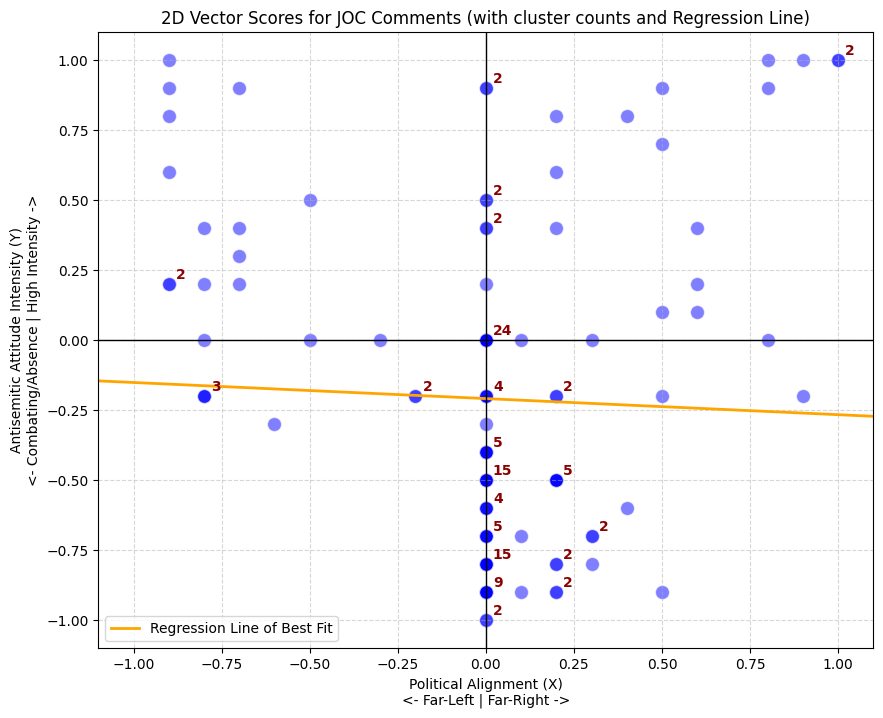

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# Load the scored dataset
joc_scored = pd.read_parquet('/content/drive/MyDrive/IS488614/jewishoncampus_scored.parquet')

# Drop any rows where X or Y might be missing to avoid grouping issues
joc_scored_clean = joc_scored.dropna(subset=['X', 'Y'])

# Fit the regression model: Y ~ X
X_train = joc_scored_clean[['X']]
y_train = joc_scored_clean['Y']
reg = LinearRegression().fit(X_train, y_train)

# Predict Y values for a line
x_range = np.linspace(-1.1, 1.1, 100).reshape(-1, 1)
y_pred = reg.predict(x_range)

# Group by identical scores to find counts
score_counts = joc_scored_clean.groupby(['X', 'Y']).size().reset_index(name='count')

# Plot the scatterplot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=joc_scored_clean, x='X', y='Y', alpha=0.5, s=100, color='blue')

# Plot the regression line
plt.plot(x_range, y_pred, color='orange', linewidth=2, label='Regression Line of Best Fit')

# Annotate points with their counts if greater than 1
for i, row in score_counts.iterrows():
    if row['count'] > 1:
        # Offset the text slightly so it doesn't overlap the point exactly
        plt.text(row['X'] + 0.02, row['Y'] + 0.02, str(int(row['count'])),
                 fontsize=10, color='darkred', weight='bold')

# Add axes lines through the origin (0,0) to show the quadrants clearly
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Set limits based on the prompt description (-1.0 to 1.0)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

# Add labels and title
plt.xlabel('Political Alignment (X)\n<- Far-Left | Far-Right ->')
plt.ylabel('Antisemitic Attitude Intensity (Y)\n<- Combating/Absence | High Intensity ->')
plt.title('2D Vector Scores for JOC Comments (with cluster counts and Regression Line)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

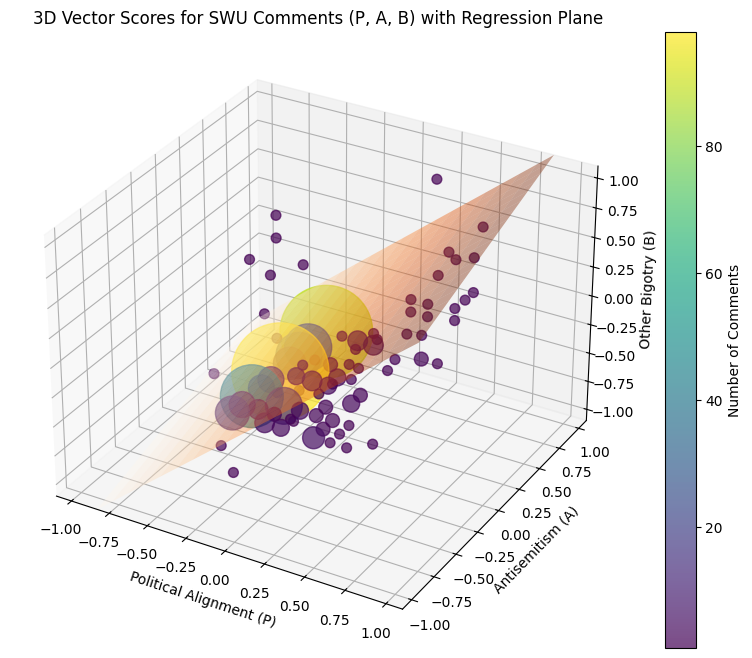

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# Load the scored dataset
swu_scored = pd.read_parquet('/content/drive/MyDrive/IS488614/standwithus_scored.parquet')
swu_scored_clean = swu_scored.dropna(subset=['P', 'A', 'B', 'Z'])

# Fit the regression model: P ~ A + B
X_train = swu_scored_clean[['A', 'B']]
y_train = swu_scored_clean['P']
reg = LinearRegression().fit(X_train, y_train)

# Create a meshgrid for A and B
a_range = np.linspace(-1.1, 1.1, 20)
b_range = np.linspace(-1.1, 1.1, 20)
a_grid, b_grid = np.meshgrid(a_range, b_range)

# Predict P values for the grid
p_grid = reg.predict(pd.DataFrame({'A': a_grid.ravel(), 'B': b_grid.ravel()})).reshape(a_grid.shape)

# Group by identical scores to calculate bubble sizes for overlapping points
score_counts_3d = swu_scored_clean.groupby(['P', 'A', 'B']).size().reset_index(name='count')

# 1. 3D Scatterplot for (P, A, B)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    score_counts_3d['P'],
    score_counts_3d['A'],
    score_counts_3d['B'],
    s=score_counts_3d['count'] * 50,  # Scale size by frequency count
    c=score_counts_3d['count'],
    cmap='viridis',
    alpha=0.7
)

# Add the regression hyperplane surface to the figure
# Note: x is P, y is A, z is B to match the scatter plot axes
ax.plot_surface(p_grid, a_grid, b_grid, alpha=0.4, cmap='Oranges')

ax.set_xlabel('Political Alignment (P)')
ax.set_ylabel('Antisemitism (A)')
ax.set_zlabel('Other Bigotry (B)')
ax.set_title('3D Vector Scores for SWU Comments (P, A, B) with Regression Plane')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_zlim(-1.1, 1.1)
fig.colorbar(sc, ax=ax, label='Number of Comments')
plt.show()

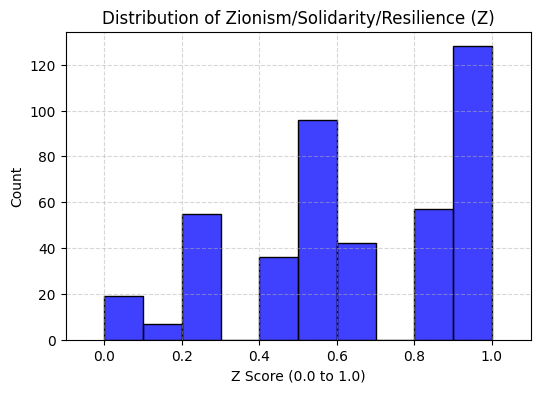

,post_id,media_code,text,comment_id,timestamp,commenter_username,text_encoded,P,A,B,Z
0,3884093490012017799_323644484,DXnEnNKktSH,"And a few other Jewish boys and girls, who wro...",unknown,1777241598,joeking583,"And a few other Jewish boys and girls, who wro...",0.0,-0.8,0.0,0.7
1,3884093490012017799_323644484,DXnEnNKktSH,Americans don’t hate Jews. They reject Israel’...,unknown,1777291111,heidinfreud,Americans don’t hate Jews. They reject Israel’...,-0.8,0.5,0.0,0.0
2,3884093490012017799_323644484,DXnEnNKktSH,And Louis Armstrong was fluent in Yiddish.,unknown,1777261461,mallwischken,And Louis Armstrong was fluent in Yiddish.,0.0,-0.2,0.0,0.2
3,3884093490012017799_323644484,DXnEnNKktSH,@tristan.tgh ❤️❤️❤️,unknown,1777240453,chef_briantsev,@tristan.tgh RED_HEART RED_HEART RED_HEART,0.0,0.0,0.0,0.5
4,3884093490012017799_323644484,DXnEnNKktSH,this is too good,unknown,1777271170,itsvegansis,this is too good,0.0,0.0,0.0,0.3
...,...,...,...,...,...,...,...,...,...,...,...
435,3883937439102706870_51793242,DXmhIXbjqS2,Baruch Dayan ha'emet May his precious neshama ...,unknown,1777233322,mordechaileviyitzhak5778,Baruch Dayan ha'emet May his precious neshama ...,0.2,-0.9,0.0,1.0
436,3883937439102706870_51793242,DXmhIXbjqS2,May he be remembered forever💔Thank you for pro...,unknown,1777232494,miritbisholt,May he be remembered forever BROKEN_HEART Than...,0.4,-0.8,0.0,1.0
437,3883937439102706870_51793242,DXmhIXbjqS2,"יהי זכרו ברוך ,כאב לב 💔🥀",unknown,1777232490,avitours,"יהי זכרו ברוך ,כאב לב BROKEN_HEART WILTED_FLOWER",0.0,-0.3,0.0,0.7
438,3883937439102706870_51793242,DXmhIXbjqS2,יהי זכרהברוך🖤💔,unknown,1777232178,sybelell,יהי זכרהברוך BLACK_HEART BROKEN_HEART,0.0,-0.3,0.0,0.7


In [ ]:
# 2. Small Bar Chart / Histogram for (Z)
plt.figure(figsize=(6, 4))
sns.histplot(data=swu_scored_clean, x='Z', bins=10, color='blue')
plt.title('Distribution of Zionism/Solidarity/Resilience (Z)')
plt.xlabel('Z Score (0.0 to 1.0)')
plt.ylabel('Count')
plt.xlim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

display(swu_scored)

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Fit the regression model: P ~ A + B
X_train = swu_scored_clean[['A', 'B']]
y_train = swu_scored_clean['P']
reg = LinearRegression().fit(X_train, y_train)

# Create a meshgrid for A and B
a_range = np.linspace(-1.1, 1.1, 20)
b_range = np.linspace(-1.1, 1.1, 20)
a_grid, b_grid = np.meshgrid(a_range, b_range)

# Predict P values for the grid
p_grid = reg.predict(pd.DataFrame({'A': a_grid.ravel(), 'B': b_grid.ravel()})).reshape(a_grid.shape)

# Create the interactive 3D scatterplot using Plotly
fig = px.scatter_3d(
    score_counts_3d,
    x='P',
    y='A',
    z='B',
    size='count',
    color='count',
    opacity=0.7,
    size_max=100,  # Scale up the maximum size of the points
    title='Interactive 3D Vector Scores for SWU Comments (P, A, B) with Regression Plane',
    labels={
        'P': 'Political Alignment (P)',
        'A': 'Antisemitism (A)',
        'B': 'Other Bigotry (B)'
    },
    color_continuous_scale='Viridis'
)

# Add the regression hyperplane surface to the figure
# Note: x is P, y is A, z is B to match the scatter plot axes
fig.add_trace(go.Surface(
    x=p_grid,
    y=a_grid,
    z=b_grid,
    opacity=0.4,
    colorscale='Oranges',
    showscale=False,
    name='Regression Plane'
))

# Lock the axes ranges to -1.1 to 1.1 for consistency with the matplotlib plot
# and increase the figure dimensions for better readability
fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-1.1, 1.1]),
        yaxis=dict(range=[-1.1, 1.1]),
        zaxis=dict(range=[-1.1, 1.1])
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    width=1000,  # Scale up the plot width
    height=800   # Scale up the plot height
)

fig.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Define the output directory
output_dir = '/content/drive/MyDrive/IS488614/'
os.makedirs(output_dir, exist_ok=True)

print("Saving high-quality plots to Google Drive...")

# 1. Top 20 Emojis - Individual Plots
fig, ax = plt.subplots(figsize=(8, 8))
plot_top_emojis(swu_emojis, 'Top 20 Emojis in SWU', ax)
plt.tight_layout()
plt.savefig(f'{output_dir}swu_top_20_emojis.png', dpi=300, bbox_inches='tight')
plt.close()
print("- Saved: swu_top_20_emojis.png")

fig, ax = plt.subplots(figsize=(8, 8))
plot_top_emojis(joc_emojis, 'Top 20 Emojis in JOC', ax)
plt.tight_layout()
plt.savefig(f'{output_dir}joc_top_20_emojis.png', dpi=300, bbox_inches='tight')
plt.close()
print("- Saved: joc_top_20_emojis.png")

# 2. Top 20 Emoji Sequences - Individual Plots
fig, ax = plt.subplots(figsize=(8, 8))
plot_top_sequences(swu_seqs, 'Top 20 Emoji Sequences in SWU', ax)
plt.tight_layout()
plt.savefig(f'{output_dir}swu_top_20_emoji_sequences.png', dpi=300, bbox_inches='tight')
plt.close()
print("- Saved: swu_top_20_emoji_sequences.png")

fig, ax = plt.subplots(figsize=(8, 8))
plot_top_sequences(joc_seqs, 'Top 20 Emoji Sequences in JOC', ax)
plt.tight_layout()
plt.savefig(f'{output_dir}joc_top_20_emoji_sequences.png', dpi=300, bbox_inches='tight')
plt.close()
print("- Saved: joc_top_20_emoji_sequences.png")

# 3. 2D Vector Scores for JOC
plt.figure(figsize=(10, 8))
sns.scatterplot(data=joc_scored_clean, x='X', y='Y', alpha=0.5, s=100, color='blue')
plt.plot(x_range, y_pred, color='orange', linewidth=2, label='Regression Line of Best Fit')
for i, row in score_counts.iterrows():
    if row['count'] > 1:
        plt.text(row['X'] + 0.02, row['Y'] + 0.02, str(int(row['count'])),
                 fontsize=10, color='darkred', weight='bold')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel('Political Alignment (X)\n<- Far-Left | Far-Right ->')
plt.ylabel('Antisemitic Attitude Intensity (Y)\n<- Combating/Absence | High Intensity ->')
plt.title('2D Vector Scores for JOC Comments (with cluster counts and Regression Line)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.savefig(f'{output_dir}joc_2d_vector_scores.png', dpi=300, bbox_inches='tight')
plt.close()
print("- Saved: joc_2d_vector_scores.png")

# 4. 3D Vector Scores for SWU (Static Matplotlib)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    score_counts_3d['P'],
    score_counts_3d['A'],
    score_counts_3d['B'],
    s=score_counts_3d['count'] * 50,
    c=score_counts_3d['count'],
    cmap='viridis',
    alpha=0.7
)
ax.plot_surface(p_grid, a_grid, b_grid, alpha=0.4, cmap='Oranges')
ax.set_xlabel('Political Alignment (P)')
ax.set_ylabel('Antisemitism (A)')
ax.set_zlabel('Other Bigotry (B)')
ax.set_title('3D Vector Scores for SWU Comments (P, A, B) with Regression Plane')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_zlim(-1.1, 1.1)
fig.colorbar(sc, ax=ax, label='Number of Comments')
plt.savefig(f'{output_dir}swu_3d_vector_scores.png', dpi=300, bbox_inches='tight')
plt.close()
print("- Saved: swu_3d_vector_scores.png")

# 5. Distribution of Zionism/Solidarity/Resilience (Z)
plt.figure(figsize=(6, 4))
sns.histplot(data=swu_scored_clean, x='Z', bins=10, color='blue')
plt.title('Distribution of Zionism/Solidarity/Resilience (Z)')
plt.xlabel('Z Score (0.0 to 1.0)')
plt.ylabel('Count')
plt.xlim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(f'{output_dir}swu_z_distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print("- Saved: swu_z_distribution.png")

# 6. Interactive 3D Vector Scores for SWU (Plotly HTML)
fig_plotly = px.scatter_3d(
    score_counts_3d,
    x='P',
    y='A',
    z='B',
    size='count',
    color='count',
    opacity=0.7,
    size_max=100,
    title='Interactive 3D Vector Scores for SWU Comments (P, A, B) with Regression Plane',
    labels={'P': 'Political Alignment (P)', 'A': 'Antisemitism (A)', 'B': 'Other Bigotry (B)'},
    color_continuous_scale='Viridis'
)
fig_plotly.add_trace(go.Surface(
    x=p_grid,
    y=a_grid,
    z=b_grid,
    opacity=0.4,
    colorscale='Oranges',
    showscale=False,
    name='Regression Plane'
))
fig_plotly.update_layout(
    scene=dict(xaxis=dict(range=[-1.1, 1.1]), yaxis=dict(range=[-1.1, 1.1]), zaxis=dict(range=[-1.1, 1.1])),
    margin=dict(l=0, r=0, b=0, t=40),
    width=1000,
    height=800
)
fig_plotly.write_html(f'{output_dir}swu_interactive_3d_scores.html')
print("- Saved: swu_interactive_3d_scores.html")

print("\nAll individual plots successfully saved to Drive!")

Saving high-quality plots to Google Drive...


/tmp/ipykernel_6523/636622176.py:33: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




- Saved: swu_top_20_emojis.png


/tmp/ipykernel_6523/636622176.py:33: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




- Saved: joc_top_20_emojis.png


/tmp/ipykernel_6523/2433142531.py:33: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




- Saved: swu_top_20_emoji_sequences.png


/tmp/ipykernel_6523/2433142531.py:33: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




- Saved: joc_top_20_emoji_sequences.png
- Saved: joc_2d_vector_scores.png
- Saved: swu_3d_vector_scores.png
- Saved: swu_z_distribution.png
- Saved: swu_interactive_3d_scores.html

All individual plots successfully saved to Drive!
